In [1]:
# =============================================================================
# Simulation-Based Power Analysis: BM Trait Evolution with Mean Shift
# Phylogenetic Mixed Models | Grass Family (Poaceae)
# =============================================================================
# DEPENDENCIES: ape, phytools, ggplot2, dplyr
# Install if needed:
#   install.packages(c("ape", "phytools", "ggplot2", "dplyr"))
# =============================================================================

library(ape)
library(phytools)
library(ggplot2)
library(dplyr)
library(asreml)
library(parallel)

Loading required package: maps


Attaching package: ‘dplyr’


The following object is masked from ‘package:ape’:

    where


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: Matrix



Online License checked out Mon Apr 13 15:41:12 2026


Loading ASReml-R version 4.2




In [2]:
# =============================================================================
# 1. TREE SETUP
# =============================================================================
# Option A: Load your own tree (Newick or Nexus)
tree <- read.tree("/workdir/sh2246/p_phyloGWAS/output/powerSimulation/tree.nwk")
# tree <- read.nexus("your_tree.nex")

# Option B: Simulated example tree (replace with your real tree)
# set.seed(42)
# tree <- rtree(n = 50)                    # 50-tip random tree
# tree <- compute.brlen(tree)              # ensure branch lengths exist
# tree$tip.label <- paste0("sp_", 1:50)   # tip labels

In [3]:
# =============================================================================
# 2. SIMULATION PARAMETERS
# =============================================================================
n_transitions <- 46        # number of independent transition branches
sigma2_Y      <- 0.5      # BM rate for Y
sigma2_X      <- 0.5      # BM rate for X (can differ from Y)
 
# Shift for Y 
shift_Y       <- 2
 
# Proportional shifts for X: beta × shift_Y
# These define your power curve x-axis (effect size of X relative to Y)
beta_range    <- 0.1  # 0 = no association, 1 = same shift as Y
 
n_X           <- 100      # number of X traits per replicate
n_sims        <- 1      # simulation replicates per beta value
alpha         <- 0.05     # significance threshold

In [ ]:
# =============================================================================
# 3. PLACE INDEPENDENT TRANSITION BRANCHES
# =============================================================================
# "Independent" = no transition node is an ancestor of another.
# Returns a vector of internal node indices.
 
 
# Get all ancestor nodes of a given node by walking up the edge matrix
get_all_ancestors <- function(tree, node) {
  ancestors <- c()
  current   <- node
  root      <- Ntip(tree) + 1
  while (current != root) {
    parent  <- tree$edge[tree$edge[, 2] == current, 1]
    if (length(parent) == 0) break
    ancestors <- c(ancestors, parent)
    current   <- parent
  }
  ancestors
}
 
sample_independent_nodes <- function(tree, n, seed = NULL) {
  if (!is.null(seed)) set.seed(seed)
 
  internal_nodes <- (Ntip(tree) + 1):(Ntip(tree) + Nnode(tree))
  # exclude root (can't define a transition above it)
  internal_nodes <- internal_nodes[-1]
 
  selected   <- c()
  candidates <- sample(internal_nodes)   # random order
 
  for (nd in candidates) {
    if (length(selected) == n) break
 
    nd_ancestors <- get_all_ancestors(tree, nd)
    nd_desc      <- phytools::getDescendants(tree, nd)
 
    # reject if nd is ancestor of any selected, or descendant of any selected
    is_ancestor_of_selected   <- any(selected %in% nd_desc)
    is_descendant_of_selected <- any(selected %in% nd_ancestors)
 
    if (!is_ancestor_of_selected && !is_descendant_of_selected) {
      selected <- c(selected, nd)
    }
  }
 
  if (length(selected) < n)
    warning(sprintf("Only found %d independent nodes (requested %d).", length(selected), n))
 
  return(selected)
}
 
# Helper: get tip labels descending from a node
get_tip_descendants <- function(tree, node) {
  desc <- phytools::getDescendants(tree, node)
  tips <- desc[desc <= Ntip(tree)]
  tree$tip.label[tips]
}
 
# Build tip regime vector from transition nodes
make_regime <- function(tree, transition_nodes) {
  regimes <- setNames(rep(0L, Ntip(tree)), tree$tip.label)  # 0 = ancestral
  for (nd in transition_nodes) {
    tips <- get_tip_descendants(tree, nd)
    regimes[tips] <- 1L   # 1 = derived
  }
  regimes
}
 

In [188]:
transition_nodes <- rjson::fromJSON(file = '/workdir/sh2246/p_phyloGWAS/output/powerSimulation/realTransition.json')[[1]]           # <-- replace with your actual nodes
real_regime = make_regime(tree,unlist(transition_nodes))

In [209]:
length(unlist(transition_nodes))

[1] 46

In [135]:
# Quick check
test_nodes  <- sample_independent_nodes(tree, length(unlist(transition_nodes)), seed = 1)
test_regime <- make_regime(tree, test_nodes)

test_nodes2  <- sample_independent_nodes(tree, length(unlist(transition_nodes))*2, seed = 1)
test_regime2 <- make_regime(tree, test_nodes2)

In [156]:
test_nodes3  <- sample_independent_nodes(tree, length(unlist(transition_nodes))*3, seed = 1)
test_regime3 <- make_regime(tree, test_nodes3)

In [157]:
cat(sprintf("\nDerived tips: %d / %d\n", sum(real_regime), Ntip(tree)))
cat(sprintf("\nDerived tips: %d / %d\n", sum(test_regime), Ntip(tree)))
cat(sprintf("\nDerived tips: %d / %d\n", sum(test_regime2), Ntip(tree)))
cat(sprintf("\nDerived tips: %d / %d\n", sum(test_regime3), Ntip(tree)))


Derived tips: 171 / 707

Derived tips: 216 / 707

Derived tips: 348 / 707

Derived tips: 470 / 707


In [182]:
# =============================================================================
# 4. SIMULATE Y AND X UNDER BM + PROPORTIONAL SHIFT
# =============================================================================
simulate_Y <- function(tree, regime, sigma2_Y, shift_Y,
                        sigma2_resid_Y = 0.25 * sigma2_Y, seed = NULL) {
  if (!is.null(seed)) set.seed(seed)
  bm_part    <- fastBM(tree, sig2 = sigma2_Y, internal = FALSE)
  resid_part <- rnorm(Ntip(tree), mean = 0, sd = sqrt(sigma2_resid_Y))
  shift_vec  <- ifelse(regime == 1, shift_Y, 0)
  bm_part + shift_vec + resid_part
}
 
# sigma2_resid_X: iid noise added to X to break perfect covariance alignment
# with Y's BM structure. 0.1 * sigma2_X.
simulate_X <- function(tree, regime, sigma2_X, shift_X,
                        sigma2_resid_X = 0.25 * sigma2_X, seed = NULL) {
  if (!is.null(seed)) set.seed(seed)
  bm_part    <- fastBM(tree, sig2 = sigma2_X, internal = FALSE)
  resid_part <- rnorm(Ntip(tree), mean = 0, sd = sqrt(sigma2_resid_X))
  shift_vec  <- ifelse(regime == 1, shift_X, 0)
  bm_part + shift_vec + resid_part
}
 
simulate_Y_and_X <- function(tree, node, prop, sigma2_Y, sigma2_X,
                              shift_Y, beta, n_X,
                              sigma2_resid_Y = 0.1 * sigma2_Y,  # residual for Y
                              sigma2_resid_X = 0.1 * sigma2_X,  # residual for X
                              seed = NULL) {
  if (!is.null(seed)) set.seed(seed)
  regime_Y = make_regime(tree,node)
 
  Y       <- simulate_Y(tree, regime_Y, sigma2_Y, shift_Y, sigma2_resid_Y)
  shift_X <- beta * shift_Y
  regime_X <- make_regime(tree,sample(node,round(length(node)*prop)))
 
  X_mat <- replicate(n_X, simulate_X(tree, regime_X, sigma2_X,
                                      shift_X, sigma2_resid_X))
  colnames(X_mat) <- paste0("X", seq_len(n_X))
  
  data.frame(assemblyID = as.factor(tree$tip.label),Y = Y, X = X_mat)
} 


In [78]:
test_sim = simulate_Y_and_X(tree,regime = test_regime,sigma2_Y,sigma2_X,shift_Y,beta = .3,1,1)

In [106]:
fit_model <- function(data, Kmat,responseVar,predictor) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE,trace = F)
    Coeff = c()
    WaldPval = c()
    for (i in predictor){
        fullFM = as.formula(paste0(responseVar, "~", i ))
        model_full <- asreml(fixed = fullFM,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = data)

        modelWald <- wald.asreml(model_full)
        if(model_full$converge) {
            Coeff <- c(Coeff,model_full$coefficients$fixed[2])
            WaldPval <- c(WaldPval,modelWald[2,4])
        }else {
            Coeff <- c(Coeff,NA)
            WaldPval <- c(WaldPval,NA)
        }
    }
    
    out = list("coeff" = Coeff, "p" = WaldPval)
#     names(out) = c(paste("Coeff",predictor,sep = "_"),
#                    paste("P",predictor,sep = "_"))
    return(out)
}

In [183]:
run_power_analysis = function(KMat,tree,node, prop,sigma2_Y,sigma2_X,shift_Y,beta,n_X,alpha = 0.05) {
    simDat = simulate_Y_and_X(tree, node, prop, sigma2_Y, sigma2_X,
                              shift_Y, beta, n_X,
                              sigma2_resid_Y = 0.1 * sigma2_Y,  # residual for Y
                              sigma2_resid_X = 0.1 * sigma2_X,  # residual for X
                              seed = 1)
    tmp = fit_model(simDat,KMat,"Y",colnames(simDat)[-c(1:2)])
    power = sum(tmp$p < alpha,na.rm = T)/n_X
    s2Y = var(simDat[,2])
    s2X = apply(simDat[,-c(1,2)],2,var)
    beta = mean(tmp$coeff*s2X/s2Y)
    return(c(beta,power))
}


In [15]:
phyloKMat <- read.table('/workdir/sh2246/p_phyloGWAS/output/phyloK_728Poaceae_astral_20250407.txt')
colnames(phyloKMat) <- rownames(phyloKMat)


In [185]:
asreml.options(maxit = 60)
run_power_analysis(phyloKMat,tree,test_nodes,prop = .5,sigma2_Y,sigma2_X,shift_Y,beta = .1,n_X = 10,alpha = 0.05)

[1] 0.02444143 0.10000000

In [126]:
length(seq(0, 0.5, by = 0.025))

[1] 21

In [137]:
# =============================================================================
# 6. POWER CURVE: vary shift magnitude
# =============================================================================
beta_range <- seq(0, 0.5, by = 0.025)
power_curve0 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,unlist(transition_nodes),prop = 1,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve1 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes, prop = 1,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve2 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes2, prop = 1,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve3 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes3, prop = 1,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

In [190]:
power_curve10 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,unlist(transition_nodes),prop = .8,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve11 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes, prop = .8,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve12 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes2, prop = .8,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve13 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes3, prop = .8,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

In [191]:
power_curve20 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,unlist(transition_nodes),prop = .5,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve21 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes, prop = .5,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve22 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes2, prop = .5,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve23 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes3, prop = .5,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

In [192]:
power_curve30 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,unlist(transition_nodes),prop = .3,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve31 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes, prop = .3,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve32 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes2, prop = .3,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

power_curve33 <- mclapply(beta_range, function(b) {
  r <- run_power_analysis(phyloKMat,tree,test_nodes3, prop = .3,
                          sigma2_Y,sigma2_X,shift_Y,
                          beta = b,n_X = 100,alpha = 0.05)  # fewer sims for speed
  return(r)
},mc.cores = 21)

In [193]:
power_df <- rbind(data.frame(t(simplify2array(power_curve0)),"X3" = rep("empirical transition",21),
                             "X4" = beta_range,"X5" = rep("100%",21)),
                  data.frame(t(simplify2array(power_curve1)),"X3" = rep("random transition - 1x",21),
                             "X4" = beta_range,"X5" = rep("100%",21)),
                  data.frame(t(simplify2array(power_curve2)),"X3" = rep("random transition - 2x",21),
                             "X4" = beta_range,"X5" = rep("100%",21)),
                  data.frame(t(simplify2array(power_curve3)),"X3" = rep("random transition - 3x",21),
                             "X4" = beta_range,"X5" = rep("100%",21)))

colnames(power_df) = c("beta_emp","power","scenario","beta","convergence")


In [199]:
power_df1 <- rbind(data.frame(t(simplify2array(power_curve10)),"X3" = rep("empirical transition",21),
                             "X4" = beta_range,"X5" = rep("80%",21)),
                  data.frame(t(simplify2array(power_curve11)),"X3" = rep("random transition - 1x",21),
                             "X4" = beta_range,"X5" = rep("80%",21)),
                  data.frame(t(simplify2array(power_curve12)),"X3" = rep("random transition - 2x",21),
                             "X4" = beta_range,"X5" = rep("80%",21)),
                  data.frame(t(simplify2array(power_curve13)),"X3" = rep("random transition - 3x",21),
                             "X4" = beta_range,"X5" = rep("80%",21)))

colnames(power_df1) = c("beta_emp","power","scenario","beta","convergence")


In [200]:
power_df2 <- rbind(data.frame(t(simplify2array(power_curve20)),"X3" = rep("empirical transition",21),
                             "X4" = beta_range,"X5" = rep("50%",21)),
                  data.frame(t(simplify2array(power_curve21)),"X3" = rep("random transition - 1x",21),
                             "X4" = beta_range,"X5" = rep("50%",21)),
                  data.frame(t(simplify2array(power_curve22)),"X3" = rep("random transition - 2x",21),
                             "X4" = beta_range,"X5" = rep("50%",21)),
                  data.frame(t(simplify2array(power_curve23)),"X3" = rep("random transition - 3x",21),
                             "X4" = beta_range,"X5" = rep("50%",21)))

colnames(power_df2) = c("beta_emp","power","scenario","beta","convergence")


In [202]:
power_df3 <- rbind(data.frame(t(simplify2array(power_curve30)),"X3" = rep("empirical transition",21),
                             "X4" = beta_range,"X5" = rep("30%",21)),
                  data.frame(t(simplify2array(power_curve31)),"X3" = rep("random transition - 1x",21),
                             "X4" = beta_range,"X5" = rep("30%",21)),
                  data.frame(t(simplify2array(power_curve32)),"X3" = rep("random transition - 2x",21),
                             "X4" = beta_range,"X5" = rep("30%",21)),
                  data.frame(t(simplify2array(power_curve33)),"X3" = rep("random transition - 3x",21),
                             "X4" = beta_range,"X5" = rep("30%",21)))

colnames(power_df3) = c("beta_emp","power","scenario","beta","convergence")


In [204]:
power_df_merged = rbind(power_df,power_df1,power_df2,power_df3)

In [207]:
power_df_merged$convergence = factor(power_df_merged$convergence,levels = c("100%","80%","50%","30%"))

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'BM rate σ² = 0.50 | 100 simulations per parameter combination' in 'mbcsToSbcs': dot substituted for <cf>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'BM rate σ² = 0.50 | 100 simulations per parameter combination' in 'mbcsToSbcs': dot substituted for <83>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'BM rate σ² = 0.50 | 100 simulations per parameter combination' in 'mbcsToSbcs': dot substituted for <cf>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'BM rate σ² = 0.50 | 100 simulations per parameter combination' in 'mbcsToSbcs': dot substituted for <83>”


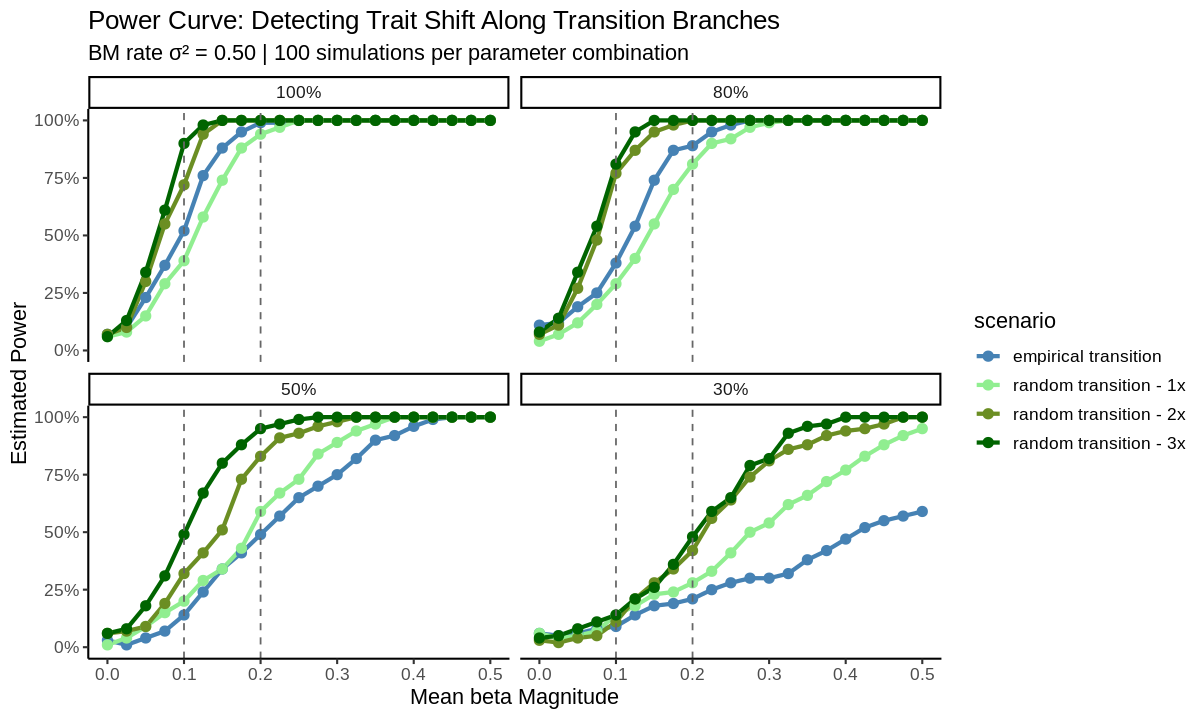

In [210]:
options(repr.plot.width=10, repr.plot.height=6)
p_curve <- ggplot(power_df_merged, aes(x = beta, y = power,color = scenario)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2.5) +
  facet_wrap(~convergence,nrow = 2)+
  scale_color_manual(values = c("steelblue","lightgreen","olivedrab", "darkgreen")) +
  geom_vline(xintercept = c(0.1,0.2), linetype = "dashed", color = "grey40") +
  labs(
    title    = "Power Curve: Detecting Trait Shift Along Transition Branches",
    subtitle = sprintf("BM rate σ² = %.2f | %d simulations per parameter combination", sigma2_Y, 100),
    x        = "Mean beta Magnitude",
    y        = "Estimated Power"
  ) +
  scale_y_continuous(limits = c(0, 1), labels = scales::percent) +
  theme_classic(base_size = 13)

print(p_curve)
# ggsave("power_curve.pdf", p_curve, width = 7, height = 5)

Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'BM rate σ² = 0.50 | 100 simulations per beta value' in 'mbcsToSbcs': dot substituted for <cf>”
Warning message in grid.Call(C_textBounds, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'BM rate σ² = 0.50 | 100 simulations per beta value' in 'mbcsToSbcs': dot substituted for <83>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'BM rate σ² = 0.50 | 100 simulations per beta value' in 'mbcsToSbcs': dot substituted for <cf>”
Warning message in grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y, :
“conversion failure on 'BM rate σ² = 0.50 | 100 simulations per beta value' in 'mbcsToSbcs': dot substituted for <83>”


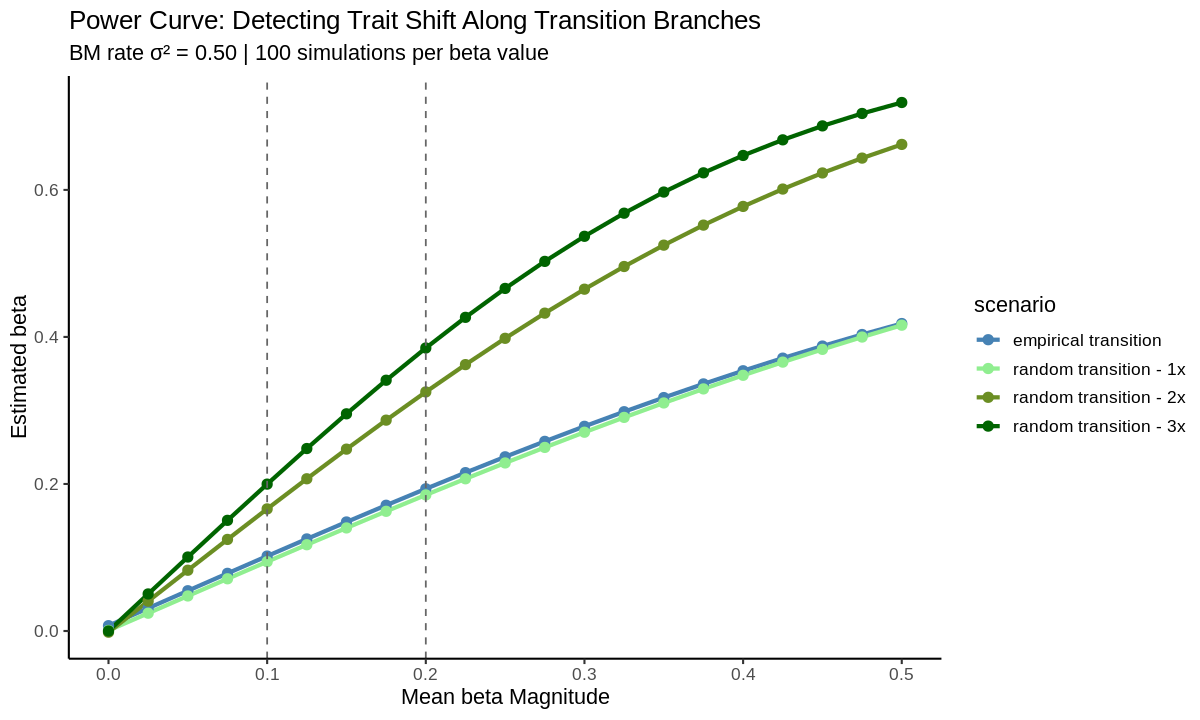

In [175]:
options(repr.plot.width=10, repr.plot.height=6)
p_curve <- ggplot(power_df, aes(x = beta, y = beta_emp,color = scenario)) +
  geom_line(linewidth = 1.2) +
  geom_point(size = 2.5) +
  scale_color_manual(values = c("steelblue","lightgreen","olivedrab", "darkgreen")) +
  geom_vline(xintercept = c(0.1,0.2), linetype = "dashed", color = "grey40") +
  labs(
    title    = "Power Curve: Detecting Trait Shift Along Transition Branches",
    subtitle = sprintf("BM rate σ² = %.2f | %d simulations per beta value", sigma2_Y, 100),
    x        = "Mean beta Magnitude",
    y        = "Estimated beta"
  ) +
#   scale_y_continuous(limits = c(0, 1), labels = scales::percent) +
  theme_classic(base_size = 13)

print(p_curve)
# ggsave("power_curve.pdf", p_curve, width = 7, height = 5)

In [63]:
sd(test_sim[tip_regimes=='ancestral'])

[1] 1.867812

In [ ]:
# =============================================================================
# 7. VISUALISE ONE SIMULATED TRAIT ON THE TREE
# =============================================================================
# Color tips by regime
regime_colors <- ifelse(tip_regimes == "ancestral", "steelblue", "firebrick")
names(regime_colors) <- names(tip_regimes)

pdf("tree_with_simulated_trait.pdf", width = 9, height = 8)
  phytools::dotTree(tree, test_sim,
                    colors  = setNames(c("steelblue","firebrick"),
                                       c("ancestral","shifted")),
                    ftype   = "off",
                    main    = "Simulated BM Trait with Mean Shift")
  legend("topleft",
         legend = c("Ancestral regime", "Shifted regime"),
         col    = c("steelblue", "firebrick"),
         pch    = 16, bty = "n")
dev.off()

cat("\nOutput files written:\n")
cat("  power_curve.pdf\n")
cat("  tree_with_simulated_trait.pdf\n")

# =============================================================================
# NEXT STEPS (swap Wilcoxon above for one of these):
# -----------------------------------------------------------------------------
# phylolm::phylolm(trait ~ regime, phy = tree, model = "BM")
# nlme::gls(trait ~ regime, correlation = corBrownian(phy = tree))
# MCMCglmm for full Bayesian phylogenetic mixed model
# =============================================================================

In [15]:
# metadata = read.delim("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_highErrorFiltered_2025.10.08.tsv",header = T)
# rownames(metadata) = metadata$assemblyID
# phyloKMat <- read.table('/workdir/sh2246/p_phyloGWAS/output/phyloK_728Poaceae_astral_20250407.txt')
# colnames(phyloKMat) <- rownames(phyloKMat)
# envData = read.table("/workdir/sh2246/p_phyloGWAS/output/envData_707Poaceae_20250804.txt")
# envDf = cbind(rownames(envData),envData)
# colnames(envDf)[1] = "assemblyID"
# envDf$assemblyID = as.factor(envDf$assemblyID)
# dat = merge(metadata,envDf,by = "assemblyID")
# rownames(dat) = dat$assemblyID
# dat$assemblyID = as.factor(dat$assemblyID)
# commonID = Reduce("intersect",list(tree$tip.label,rownames(envDf),metadata$assemblyID))
# length(commonID)

# length(test_sim[commonID])